# Provenance-Polarity Gate: Multi-Regime Dataset (4 Sources, 1995 Rows)

This notebook demonstrates the dataset preparation pipeline for the **Provenance-Polarity Gate** experiment.

The script loads and standardizes four reasoning datasets into the `exp_sel_data_out` JSON schema, each representing a different *inference regime*:

| Dataset | Regime | Task |
|---|---|---|
| CLUTRR/v1 | `universal_rule` | Kinship-chain reasoning |
| hitachi-nlp/proofwriter_processed_OWA | `universal_rule` | Logical inference over theory+questions |
| nguyen-brat/entailment_bank | `universal_rule` | Science QA with CoT proof |
| lighteval/synthetic_reasoning_natural (hard) | `document_stipulated` | Synthetic if-then rule chains |

The key experimental question: does a model identify *where* the bridging rule comes from — the document itself, or world knowledge?

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab
_pip('loguru==0.7.3')

# Core packages pre-installed on Colab — install locally only
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0', 'pandas==2.2.2')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6bdeab-provenance-polarity-gating-a-framework-f/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} datasets")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 4 datasets
  CLUTRR/v1: 3 examples
  hitachi-nlp/proofwriter_processed_OWA: 3 examples
  nguyen-brat/entailment_bank: 3 examples
  lighteval/synthetic_reasoning_natural: 3 examples


## Config

Tunable parameters for this demo. For a full run, restore the original values in comments.

In [5]:
SEED = 42

# Number of examples to sample per dataset (original: 500 each)
N_CLUTRR = 3         # original: 500
N_PROOFWRITER = 3    # original: 125 per depth (500 total across depth 0-3)
N_PER_DEPTH = 1      # original: 125
N_ENTAILMENTBANK = 3 # original: 500
N_SYNTHETIC = 3      # original: 500

## Helper Functions

`make_example` standardizes every row into the `exp_sel_data_out` schema: `input`, `output`, `metadata_regime`, `metadata_source_dataset`, plus any extra `metadata_*` fields.

In [6]:
def make_example(
    input_text: str,
    output_text: str,
    regime: str,
    source_dataset: str,
    **meta,
) -> dict:
    ex: dict = {
        "input": input_text,
        "output": output_text,
        "metadata_regime": regime,
        "metadata_source_dataset": source_dataset,
    }
    for k, v in meta.items():
        ex[f"metadata_{k}"] = v
    return ex

## Dataset Processing

Each function below processes one dataset from the loaded demo data.

### Dataset 1: CLUTRR/v1 — Kinship Reasoning (`universal_rule`)

Stories describe kinship relations between named entities. The model must apply general world-knowledge axioms (e.g., "sibling of parent = aunt/uncle") to resolve multi-hop queries. Stratified by hop depth (1–8).

In [7]:
def process_clutrr(rows: list, n: int = 500) -> list:
    """CLUTRR v1 — kinship reasoning (universal_rule regime)."""
    rng = random.Random(SEED)
    # stratify by task_name (hop depth)
    by_task: dict = {}
    for row in rows:
        by_task.setdefault(row.get("metadata_task_name", "unknown"), []).append(row)
    sampled = []
    tasks = sorted(by_task)
    per_task = max(1, n // max(len(tasks), 1))
    for task in tasks:
        bucket = by_task[task]
        rng.shuffle(bucket)
        sampled.extend(bucket[:per_task])
    rng.shuffle(sampled)
    sampled = sampled[:n]
    examples = []
    for row in sampled:
        examples.append(make_example(
            input_text=row["input"],
            output_text=row["output"],
            regime=row["metadata_regime"],
            source_dataset=row["metadata_source_dataset"],
            hop_depth=row.get("metadata_hop_depth", 0),
            f_comb=row.get("metadata_f_comb", ""),
            gold_premises=row.get("metadata_gold_premises", ""),
            task_name=row.get("metadata_task_name", ""),
        ))
    logger.info(f"CLUTRR: {len(examples)} examples")
    return examples

# Get CLUTRR rows from loaded data
clutrr_rows = next(d["examples"] for d in data["datasets"] if d["dataset"] == "CLUTRR/v1")
clutrr_examples = process_clutrr(clutrr_rows, n=N_CLUTRR)
print(f"Sample CLUTRR input:\n{clutrr_examples[0]['input'][:300]}")
print(f"Output: {clutrr_examples[0]['output']}")

09:33:20|INFO   |CLUTRR: 3 examples


Sample CLUTRR input:
Story: [Robert] love his brother [Ryan]. They are always playing together. [Michael] loves to play baseball with his dad, [Robert]. [April] took her nephew [Michael] to the park to play soccer.
Query: What is the relationship between ('Ryan', 'April')?
Output: sister


### Dataset 2: ProofWriter OWA — Logical Inference (`universal_rule`)

Theory+question pairs where rules are explicitly stated inside the document (document-stipulated bridging premises). Pre-split by OWA depth 0–3. Gold proof trees show exact inference steps.

In [8]:
def process_proofwriter_owa(rows: list, n_per_depth: int = 125) -> list:
    """hitachi-nlp ProofWriter OWA (universal_rule regime)."""
    rng = random.Random(SEED)
    rng.shuffle(rows)
    examples = []
    for row in rows[:n_per_depth]:
        examples.append(make_example(
            input_text=row["input"],
            output_text=row["output"],
            regime=row["metadata_regime"],
            source_dataset=row["metadata_source_dataset"],
            hop_depth=row.get("metadata_hop_depth", 0),
            proof_tree=row.get("metadata_proof_tree", ""),
        ))
    logger.info(f"ProofWriter OWA: {len(examples)} examples")
    return examples

pw_rows = next(d["examples"] for d in data["datasets"] if "proofwriter" in d["dataset"])
pw_examples = process_proofwriter_owa(pw_rows, n_per_depth=N_PER_DEPTH)
print(f"Sample ProofWriter input:\n{pw_examples[0]['input'][:300]}")
print(f"Output: {pw_examples[0]['output']}")

09:33:20|INFO   |ProofWriter OWA: 1 examples


Sample ProofWriter input:
Theory:
Gary is big. Gary is cold. Gary is not green. Gary is quiet. Gary is red. Gary is rough. Gary is white. Quiet, big people are white. Green people are white. All green people are cold.

Question: Gary is not green.
Output: True


### Dataset 3: EntailmentBank — Science QA with CoT (`universal_rule`)

Science questions requiring world-knowledge bridging rules with no context document. Gold chain-of-thought proofs provide step-by-step entailment chains. Tests pure world-knowledge rule retrieval.

In [9]:
def process_entailment_bank(rows: list, n: int = 500) -> list:
    """nguyen-brat/entailment_bank — science QA with CoT proof (universal_rule)."""
    rng = random.Random(SEED)
    rng.shuffle(rows)
    examples = []
    for row in rows[:n]:
        examples.append(make_example(
            input_text=row["input"],
            output_text=row["output"],
            regime=row["metadata_regime"],
            source_dataset=row["metadata_source_dataset"],
            proof=row.get("metadata_proof", ""),
        ))
    logger.info(f"EntailmentBank: {len(examples)} examples")
    return examples

eb_rows = next(d["examples"] for d in data["datasets"] if "entailment_bank" in d["dataset"])
eb_examples = process_entailment_bank(eb_rows, n=N_ENTAILMENTBANK)
print(f"Sample EntailmentBank input:\n{eb_examples[0]['input'][:300]}")
print(f"Output: {eb_examples[0]['output']}")

09:33:20|INFO   |EntailmentBank: 3 examples


Sample EntailmentBank input:
Question: Frame construction predominates in the New England area due to the abundance of
Output: wood.


### Dataset 4: Synthetic Reasoning Natural (hard) — Document-Stipulated Rules

Synthetic if-then rule chains embedded directly in the input text. Rules are unambiguously document-stipulated — no world knowledge needed. Clean, controlled baseline for the polarity gate.

In [10]:
def process_synthetic_reasoning(rows: list, n: int = 500) -> list:
    """lighteval/synthetic_reasoning_natural hard (document_stipulated regime)."""
    rng = random.Random(SEED)
    rng.shuffle(rows)
    examples = []
    for row in rows[:n]:
        examples.append(make_example(
            input_text=row["input"],
            output_text=row["output"],
            regime=row["metadata_regime"],
            source_dataset=row["metadata_source_dataset"],
        ))
    logger.info(f"Synthetic Reasoning: {len(examples)} examples")
    return examples

sr_rows = next(d["examples"] for d in data["datasets"] if "synthetic_reasoning" in d["dataset"])
sr_examples = process_synthetic_reasoning(sr_rows, n=N_SYNTHETIC)
print(f"Sample Synthetic Reasoning input:\n{sr_examples[0]['input'][:300]}")
print(f"Output: {sr_examples[0]['output']}")

09:33:20|INFO   |Synthetic Reasoning: 3 examples


Sample Synthetic Reasoning input:
If a cow is small or smart, then the cow is beautiful.
If a cow is red or purple, then the cow is fast.
If an animal is bad, then the animal is good.
If an animal is scary, then the animal is hot.
If a cow is blue, then the cow is big.
Fact:
The cow is purple and antique.
The following can be determ
Output: The cow is fast.


## Assemble Output

Combine all processed datasets into the final `exp_sel_data_out` schema.

In [11]:
all_datasets = [
    {"dataset": "CLUTRR/v1",                                    "examples": clutrr_examples},
    {"dataset": "hitachi-nlp/proofwriter_processed_OWA",        "examples": pw_examples},
    {"dataset": "nguyen-brat/entailment_bank",                  "examples": eb_examples},
    {"dataset": "lighteval/synthetic_reasoning_natural",        "examples": sr_examples},
]

out = {"datasets": all_datasets}
total = sum(len(d["examples"]) for d in all_datasets)
logger.info(f"Total examples: {total}")
for d in all_datasets:
    logger.info(f"  {d['dataset']}: {len(d['examples'])} examples")

09:33:20|INFO   |Total examples: 10


09:33:20|INFO   |  CLUTRR/v1: 3 examples


09:33:20|INFO   |  hitachi-nlp/proofwriter_processed_OWA: 1 examples


09:33:20|INFO   |  nguyen-brat/entailment_bank: 3 examples


09:33:20|INFO   |  lighteval/synthetic_reasoning_natural: 3 examples


## Results Visualization

Summary of the assembled dataset: examples per source, regime distribution, and hop-depth spread for CLUTRR.

Total examples: 10
dataset                      regime             
entailment_bank              universal_rule         3
proofwriter_processed_OWA    universal_rule         1
synthetic_reasoning_natural  document_stipulated    3
v1                           universal_rule         3



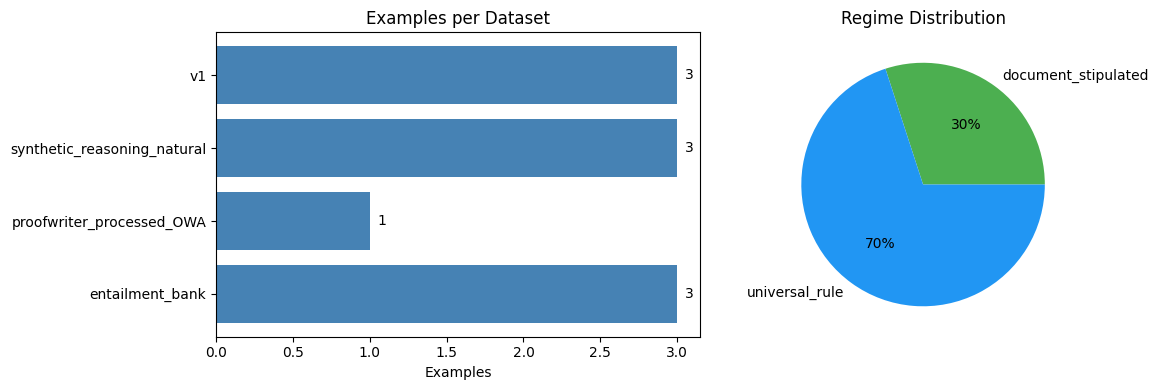

In [12]:
# Flatten all examples for analysis
all_examples = [ex for d in all_datasets for ex in d["examples"]]

# Build summary dataframe
rows_summary = []
for d in all_datasets:
    for ex in d["examples"]:
        rows_summary.append({
            "dataset": d["dataset"].split("/")[-1],
            "regime": ex["metadata_regime"],
            "hop_depth": ex.get("metadata_hop_depth", None),
        })
df = pd.DataFrame(rows_summary)

print(f"{'='*50}")
print(f"Total examples: {len(df)}")
print(f"{'='*50}")
print(df.groupby(["dataset", "regime"]).size().rename("count").to_string())
print()

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Examples per dataset
counts = df.groupby("dataset").size()
axes[0].barh(counts.index, counts.values, color="steelblue")
axes[0].set_xlabel("Examples")
axes[0].set_title("Examples per Dataset")
for i, v in enumerate(counts.values):
    axes[0].text(v + 0.05, i, str(v), va="center")

# Regime distribution
regime_counts = df.groupby("regime").size()
axes[1].pie(regime_counts.values, labels=regime_counts.index, autopct="%1.0f%%",
            colors=["#4CAF50", "#2196F3", "#FF9800"])
axes[1].set_title("Regime Distribution")

plt.tight_layout()
plt.show()

# CLUTRR hop-depth distribution
clutrr_df = df[df["hop_depth"].notna() & (df["dataset"] == "CLUTRR")]
if not clutrr_df.empty:
    print("\nCLUTRR hop-depth distribution:")
    print(clutrr_df["hop_depth"].value_counts().sort_index().to_string())